# TF-QKD Simulation — Phase 1 & Phase 2
### Based on: *Simple security proof of twin-field type quantum key distribution protocol*
### Curty, Azuma & Lo (2018) · arXiv:1807.07667v2

---
**Author:** Anand Ambastha  
**Phase 1:** Channel model, Eqs. (27)–(35)  
**Phase 2:** Cat states, phase-error bound (Eqs. 12–13, 20–22), preliminary key rate  
**Status:** Research-grade — asymptotic infinite-decoy; no α optimisation

---

## 1 · Introduction

### 1.1 Twin-Field QKD and the Square-Root Scaling

Classical point-to-point QKD is fundamentally limited by the PLOB bound [Pirandola et al., 2017],
which states that the secret key rate $R$ scales **linearly** with the channel transmittance $\eta$:
$$R \lesssim -\log_2(1-\eta) \approx \eta \quad (\eta \ll 1).$$
For a 1000 km telecom fibre (0.2 dB/km loss) this renders practical QKD essentially impossible
without trusted or quantum repeater nodes.

**Twin-Field (TF) QKD** [Lucamarini et al., 2018] is a radical departure: it exploits
*single-photon interference* at a central measurement station $C$, so that a detection event
requires only **one** photon to travel half the total distance.  
As a result the key rate scales as $\sqrt{\eta}$ — a dramatic improvement that can beat the PLOB bound.

### 1.2 Why TF-QKD differs from MDI-QKD

Standard MDI-QKD relies on **two-photon coincidence** events: one photon from Alice and one from
Bob must arrive at $C$ simultaneously and interfere.  The success probability therefore scales as
$\eta_A \times \eta_B \sim \eta$.  
TF-QKD needs only a **single** photon (from either Alice or Bob) to reach $C$, giving a success
probability $\sim \sqrt{\eta}$.

### 1.3 Protocol 3 (Curty-Azuma-Lo 2018)

The paper introduces three conceptually nested protocols.  **Protocol 3** is the practically
realisable version:

| Basis | State | Purpose |
|-------|-------|----------|
| X (key gen.) | Coherent states $|\pm\alpha\rangle$ | Raw key bits |
| Z (test) | Phase-randomised coherent states $\hat{\rho}_{\beta}$ | Decoy-state estimation |

- **Local** phase randomisation only — no global-phase matching needed.
- Security proved via Koashi's complementarity framework.
- Key rate lower bound: $R^{\mathrm{low}}_X = R^{\mathrm{low}}_{X,10} + R^{\mathrm{low}}_{X,01}$
  (Eqs. 16–19 of the paper).

### 1.4 Gains and Yields — notation guide

| Symbol | Meaning |
|--------|---------|
| $p_{XX}(k_c,k_d\mid b_A,b_B)$ | X-basis gain: prob. of detector pattern $(k_c,k_d)$ given bits $b_A,b_B$ |
| $p_{XX}(k_c,k_d)$ | Marginal X-basis gain (averaged over bits) |
| $e_{X,k_ck_d}$ | X-basis bit-error rate |
| $p_{ZZ}(k_c,k_d\mid\beta_A,\beta_B)$ | Z-basis gain for coherent amplitudes $\beta_A,\beta_B$ |
| $p_{ZZ}(k_c,k_d\mid n_A,n_B)$ | Photon-number yield (Fock inputs $n_A,n_B$) |
| $\gamma$ | Effective channel parameter $\gamma = \sqrt{\eta}\,\alpha^2$ |

Throughout, **only events with $k_c \oplus k_d = 1$** (exactly one detector fires) are accepted
as valid sifted rounds.  All equations in the paper's Appendix are written under this convention.

### 1.5 Scope of Phase 1

This notebook builds the **channel model foundation**:
- Binary entropy, omega function, $f^\pm$
- X-basis gains ($p_{XX}$, $q_{XX}$, $e_X$) — Eqs. (27)–(31)
- Z-basis gains ($p_{ZZ}$, $q_{ZZ}$) — Eqs. (32)–(33)
- Photon-number yields — Eq. (34)
- Modular decomposition of Eq. (35)
- Sanity checks and diagnostic plots

**Not in Phase 1:** finite decoy LP (Eq. 26), phase-error upper bound (Eq. 20–21),
key rate optimisation.

## 2 · Theory Overview

### Key equations implemented in this notebook

$$\Omega(\phi,\theta) = \cos\phi\cos\theta \tag{Appendix}$$

$$f^\pm_{(\theta,\phi,\gamma)} = e^{-\gamma[1 \pm \Omega(\phi,\theta)]} - e^{-2\gamma} \tag{29}$$

$$q_{XX}(k_c,k_d\mid b_A,b_B) = \begin{cases} f^- & k_c\oplus b_A \oplus b_B = 1 \\ f^+ & k_c\oplus b_A \oplus b_B = 0 \end{cases} \tag{28}$$

$$p_{XX}(k_c,k_d\mid b_A,b_B) = (1-p_d)\left[p_d\,e^{-2\gamma} + q_{XX}(k_c,k_d\mid b_A,b_B)\right] \tag{27}$$

$$p_{XX}(k_c,k_d) = \tfrac{1}{2}(1-p_d)\left(e^{-\gamma\Omega}+e^{\gamma\Omega}\right)e^{-\gamma} - (1-p_d)^2 e^{-2\gamma} \tag{30}$$

$$e_{X,k_ck_d} = \frac{e^{-\gamma\Omega} - (1-p_d)e^{-\gamma}}{e^{-\gamma\Omega}+e^{\gamma\Omega} - 2(1-p_d)e^{-\gamma}} \tag{31}$$

$$p_{ZZ}(k_c,k_d\mid\beta_A,\beta_B) = (1-p_d)\left[p_d\,e^{-(\beta_A^2+\beta_B^2)\sqrt{\eta}} + q_{ZZ}\right] \tag{32}$$

$$q_{ZZ}(k_c,k_d\mid\beta_A,\beta_B) = e^{-\frac{(\beta_A^2+\beta_B^2)\sqrt{\eta}}{2}}I_0(\beta_A\beta_B\sqrt{\eta}\cos\theta) - e^{-(\beta_A^2+\beta_B^2)\sqrt{\eta}} \tag{33}$$

$$p_{ZZ}(k_c,k_d\mid n_A,n_B) = (1-p_d)\left[p_d(1-\sqrt{\eta})^{n_A+n_B} + q_{ZZ}(k_c,k_d\mid n_A,n_B)\right] \tag{34}$$

The full form of $q_{ZZ}(k_c,k_d\mid n_A,n_B)$ is given by Eq. (35) — a nested combinatorial sum
over beam-splitter output modes — implemented modularly below.

## 3 · Imports

In [ ]:
# ─────────────────────────────────────────────────────────────
# Standard scientific stack — all available in Google Colab
# ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

from scipy.special import (
    i0 as bessel_i0,   # Modified Bessel function I_0(z) — used in q_ZZ
    comb,              # Binomial coefficient C(n, k) with exact integer arithmetic
    factorial,         # k!  (float64 for moderate k)
)

warnings.filterwarnings('ignore', category=RuntimeWarning)  # suppress log(0) warnings

# Pretty plots
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
    'lines.linewidth': 1.8,
})

print('Imports OK — numpy', np.__version__)

Imports OK — numpy 2.0.2


## 4 · Global Simulation Parameters

All physical parameters live in one dictionary — modify here to run different scenarios.

In [ ]:
# ─────────────────────────────────────────────────────────────
# GLOBAL SIMULATION PARAMETERS
# Reference: Appendix of Curty-Azuma-Lo 2018
# ─────────────────────────────────────────────────────────────

PARAMS = dict(
    # ── Detector dark-count probability per pulse ──────────────
    pd = 1e-7,

    # ── Signal amplitude α > 0 for X-basis coherent states ────
    # (γ = sqrt(η) · α²  is derived from this)
    alpha = 0.2,

    # ── Polarisation misalignment angles [radians] ─────────────
    # Paper uses θ_A = -θ_B = arcsin(√0.02)  ≈ 8.13° ≈ 2% misalignment
    thetaA =  np.arcsin(np.sqrt(0.02)),   # Alice–C channel
    thetaB = -np.arcsin(np.sqrt(0.02)),   # Bob–C  channel

    # ── Phase-mismatch parameter δ  (φ = δ·π) ─────────────────
    # δ = 0 → no phase mismatch (used in Fig. 1 of the paper)
    delta = 0.0,

    # ── Loss sweep: overall Alice–Bob loss in dB ───────────────
    # Note: η here is the *total* transmittance Alice→Bob;
    # each half-link has transmittance √η.
    loss_dB_range = np.linspace(0, 120, 300),
)

# ── Derived convenience: composite misalignment angle ─────────
PARAMS['theta'] = PARAMS['thetaA'] - PARAMS['thetaB']   # θ = θ_A − θ_B
PARAMS['phi']   = PARAMS['delta'] * np.pi                # φ = δ·π

# ── Helper: convert dB loss to transmittance η ────────────────
def dB_to_eta(loss_dB: np.ndarray) -> np.ndarray:
    """Overall transmittance η = 10^(−loss_dB / 10).

    Each Alice–C and Bob–C half-link has transmittance √η.
    """
    return 10.0 ** (-np.asarray(loss_dB, dtype=np.float64) / 10.0)


# ── Quick summary ──────────────────────────────────────────────
print('Global parameters:')
for k, v in PARAMS.items():
    if k == 'loss_dB_range':
        print(f'  {k:20s}: linspace({v[0]:.0f}, {v[-1]:.0f}, {len(v)})')
    elif isinstance(v, float):
        print(f'  {k:20s}: {v:.6g}')
    else:
        print(f'  {k:20s}: {v}')

Global parameters:
  pd                  : 1e-07
  alpha               : 0.2
  thetaA              : 0.141897
  thetaB              : -0.141897
  delta               : 0
  loss_dB_range       : linspace(0, 120, 300)
  theta               : 0.283794
  phi                 : 0


## 5 · Binary Entropy Function

$$h(x) = -x\log_2 x - (1-x)\log_2(1-x), \quad x\in[0,1]$$

Special cases: $h(0) = h(1) = 0$ (by continuity / L'Hôpital).

In [ ]:
def h(x: np.ndarray) -> np.ndarray:
    """Binary entropy  h(x) = -x log2(x) - (1-x) log2(1-x).

    Numerically safe:
    - Returns 0 at x = 0 or x = 1  (boundary convention).
    - Clips x to [0, 1] to guard against tiny numerical over/underflow.
    - Vectorised over numpy arrays.

    Parameters
    ----------
    x : float or ndarray
        Probability value(s) in [0, 1].

    Returns
    -------
    ndarray  — binary entropy, range [0, 1] bits.
    """
    x = np.asarray(x, dtype=np.float64)
    x = np.clip(x, 0.0, 1.0)

    # np.where avoids 0*log(0) = nan; both 0·(-inf) branches return 0
    term1 = np.where(x   > 0.0, -x       * np.log2(np.where(x   > 0.0, x,   1.0)), 0.0)
    term2 = np.where(1-x > 0.0, -(1.0-x) * np.log2(np.where(1-x > 0.0, 1-x, 1.0)), 0.0)
    return term1 + term2


# ── Quick validation ───────────────────────────────────────────
test_vals = {0.0: 0.0, 0.5: 1.0, 1.0: 0.0, 0.11: None}
for xv, expected in test_vals.items():
    hv = float(h(xv))
    status = '' if (expected is None or abs(hv - expected) < 1e-12) else '✗'
    print(f'  h({xv:.2f}) = {hv:.8f}   {status}')

  h(0.00) = 0.00000000   ✓
  h(0.50) = 1.00000000   ✓
  h(1.00) = 0.00000000   ✓
  h(0.11) = 0.49991596   ✓


## 6 · Channel Model

### 6.1 Omega function

$$\Omega(\phi, \theta) = \cos\phi\,\cos\theta$$

Captures the joint effect of **phase mismatch** ($\phi$) and **polarisation misalignment** ($\theta$).
When $\phi=0$ and $\theta=0$ (ideal) $\Omega=1$, maximising interference.

### 6.2 Functions $f^\pm$  (Eq. 29)

$$f^\pm_{(\theta,\phi,\gamma)} = e^{-\gamma[1\pm\Omega(\phi,\theta)]} - e^{-2\gamma}$$

These represent the click probabilities (without dark counts) for the constructive/destructive
interference arms.  $\gamma = \sqrt{\eta}\,\alpha^2$.

In [ ]:
# ─────────────────────────────────────────────────────────────
# 6.1  Ω(φ, θ) — joint phase and polarisation factor
# ─────────────────────────────────────────────────────────────
def omega(phi: float, theta: float) -> float:
    """Ω(φ, θ) = cos(φ) · cos(θ).

    Parameters
    ----------
    phi   : phase mismatch angle φ = δ·π  [radians]
    theta : composite polarisation angle θ = θ_A − θ_B  [radians]

    Returns
    -------
    float in [−1, 1]
    """
    return np.cos(phi) * np.cos(theta)


# ─────────────────────────────────────────────────────────────
# 6.2  f⁺ and f⁻  — gain functions without dark counts (Eq. 29)
# ─────────────────────────────────────────────────────────────
def f_plus(phi: float, theta: float, gamma: np.ndarray) -> np.ndarray:
    """f⁺(θ,φ,γ) = exp(−γ[1 + Ω(φ,θ)]) − exp(−2γ).

    Corresponds to *constructive* interference (detector Dc) when
    k_c ⊕ b_A ⊕ b_B = 0.

    Parameters
    ----------
    phi, theta : float  — channel angles [rad]
    gamma      : ndarray — effective channel parameter γ = √η · α²

    Returns
    -------
    ndarray, same shape as gamma.
    """
    Omega = omega(phi, theta)
    gamma = np.asarray(gamma, dtype=np.float64)
    return np.exp(-gamma * (1.0 + Omega)) - np.exp(-2.0 * gamma)


def f_minus(phi: float, theta: float, gamma: np.ndarray) -> np.ndarray:
    """f⁻(θ,φ,γ) = exp(−γ[1 − Ω(φ,θ)]) − exp(−2γ).

    Corresponds to *destructive* interference when k_c ⊕ b_A ⊕ b_B = 1.
    """
    Omega = omega(phi, theta)
    gamma = np.asarray(gamma, dtype=np.float64)
    return np.exp(-gamma * (1.0 - Omega)) - np.exp(-2.0 * gamma)


# ── Sanity: at γ=0, both f± = 0 (no signal → no clicks) ─────
print('f_plus  at γ=0:', f_plus(0.0, 0.0, 0.0))   # expect 0
print('f_minus at γ=0:', f_minus(0.0, 0.0, 0.0))  # expect 0
print('Ω(φ=0, θ=0) =', omega(0.0, 0.0))           # expect 1.0

f_plus  at γ=0: 0.0
f_minus at γ=0: 0.0
Ω(φ=0, θ=0) = 1.0


## 7 · X-Basis Implementation

### Equations implemented here
- **Eq. (28):** $q_{XX}(k_c,k_d\mid b_A,b_B)$ — gain without dark counts
- **Eq. (27):** $p_{XX}(k_c,k_d\mid b_A,b_B)$ — conditional X-basis gain
- **Eq. (30):** $p_{XX}(k_c,k_d)$ — total (marginal) X-basis gain
- **Eq. (31):** $e_{X,k_ck_d}$ — bit-error rate

In [ ]:
# ─────────────────────────────────────────────────────────────
# 7.1  q_XX  — X-basis gain without dark counts  (Eq. 28)
#
# q_XX = { f⁻   if  k_c ⊕ b_A ⊕ b_B = 1
#         { f⁺   if  k_c ⊕ b_A ⊕ b_B = 0
#
# XOR rule: the "wrong" arm (destructive) fires when exactly one
# of {k_c, b_A, b_B} is 1  (odd parity → f⁻).
# ─────────────────────────────────────────────────────────────
def q_xx(
    kc: int,
    bA: int,
    bB: int,
    phi: float,
    theta: float,
    gamma: np.ndarray,
) -> np.ndarray:
    """q_XX(k_c, k_d | b_A, b_B) — Eq. (28).

    Note: k_d is determined by k_d = 1 − k_c  (exactly one detector clicks).

    Parameters
    ----------
    kc       : int  0 or 1 — detector Dc outcome
    bA, bB   : int  0 or 1 — Alice's and Bob's bit values
    phi      : float — phase mismatch [rad]
    theta    : float — composite polarisation angle [rad]
    gamma    : ndarray — effective channel parameter γ = √η · α²

    Returns
    -------
    ndarray — q_XX values, same shape as gamma.
    """
    xor_val = int(kc) ^ int(bA) ^ int(bB)   # XOR parity
    if xor_val == 1:
        return f_minus(phi, theta, gamma)     # destructive interference
    else:
        return f_plus(phi, theta, gamma)      # constructive interference


# ─────────────────────────────────────────────────────────────
# 7.2  p_XX conditional — Eq. (27)
#
# p_XX(k_c,k_d | b_A,b_B) = (1−p_d) · [ p_d · exp(−2γ) + q_XX ]
# ─────────────────────────────────────────────────────────────
def p_xx_conditional(
    kc: int,
    bA: int,
    bB: int,
    phi: float,
    theta: float,
    gamma: np.ndarray,
    pd: float,
) -> np.ndarray:
    """Conditional X-basis gain — Eq. (27).

    p_XX(k_c, k_d | b_A, b_B) = (1 − p_d) · [p_d · exp(−2γ) + q_XX]

    Parameters
    ----------
    kc, bA, bB : int  0 or 1
    phi, theta : float [rad]
    gamma      : ndarray — γ = √η · α²
    pd         : float — dark-count probability

    Returns
    -------
    ndarray — probability, range [0, 1].
    """
    gamma = np.asarray(gamma, dtype=np.float64)
    qxx   = q_xx(kc, bA, bB, phi, theta, gamma)
    return (1.0 - pd) * (pd * np.exp(-2.0 * gamma) + qxx)


# ─────────────────────────────────────────────────────────────
# 7.3  p_XX total (marginal)  — Eq. (30)
#
# p_XX(k_c,k_d) = (1/2)(1−p_d)(exp(−γΩ) + exp(+γΩ)) exp(−γ)
#                 − (1−p_d)² exp(−2γ)
# ─────────────────────────────────────────────────────────────
def p_xx_total(
    phi: float,
    theta: float,
    gamma: np.ndarray,
    pd: float,
) -> np.ndarray:
    """Total (marginal) X-basis gain p_XX(k_c, k_d) — Eq. (30).

    This is averaged over b_A, b_B ∈ {0,1} (uniform prior).  The result
    is the same for both (k_c,k_d) = (1,0) and (0,1) by symmetry.

    Parameters
    ----------
    phi, theta : float [rad]
    gamma      : ndarray — γ = √η · α²
    pd         : float — dark-count probability

    Returns
    -------
    ndarray — marginal gain, range [0, 1].
    """
    gamma = np.asarray(gamma, dtype=np.float64)
    Omega = omega(phi, theta)
    term1 = 0.5 * (1.0 - pd) * (np.exp(-gamma * Omega) + np.exp(gamma * Omega)) * np.exp(-gamma)
    term2 = (1.0 - pd) ** 2 * np.exp(-2.0 * gamma)
    return term1 - term2


# ─────────────────────────────────────────────────────────────
# 7.4  X-basis bit-error rate  — Eq. (31)
#
# e_X = [exp(−γΩ) − (1−p_d)·exp(−γ)] /
#        [exp(−γΩ) + exp(+γΩ) − 2(1−p_d)·exp(−γ)]
#
# This is identical for both (k_c,k_d) = (1,0) and (0,1).
# ─────────────────────────────────────────────────────────────
def bit_error_rate(
    phi: float,
    theta: float,
    gamma: np.ndarray,
    pd: float,
) -> np.ndarray:
    """X-basis bit-error rate e_X — Eq. (31).

    Parameters
    ----------
    phi, theta : float [rad]
    gamma      : ndarray — γ = √η · α²
    pd         : float — dark-count probability

    Returns
    -------
    ndarray — error rate in [0, 0.5].
    """
    gamma = np.asarray(gamma, dtype=np.float64)
    Omega = omega(phi, theta)
    num   = np.exp(-gamma * Omega) - (1.0 - pd) * np.exp(-gamma)
    den   = np.exp(-gamma * Omega) + np.exp(gamma * Omega) - 2.0 * (1.0 - pd) * np.exp(-gamma)
    # Guard against 0/0 when γ→∞ (no signal, no events)
    return np.where(np.abs(den) > 1e-300, num / den, 0.5)


print('X-basis functions defined.')

X-basis functions defined.


## 8 · Z-Basis Implementation

### Equations implemented here
- **Eq. (33):** $q_{ZZ}(k_c,k_d\mid\beta_A,\beta_B)$ — Z gain without dark counts (uses $I_0$)
- **Eq. (32):** $p_{ZZ}(k_c,k_d\mid\beta_A,\beta_B)$ — Z-basis gain

In [ ]:
# ─────────────────────────────────────────────────────────────
# 8.1  q_ZZ — Z-basis gain without dark counts  (Eq. 33)
#
# q_ZZ = exp(−(βA²+βB²)√η / 2) · I₀(βA·βB·√η·cosθ)
#       − exp(−(βA²+βB²)√η)
#
# I₀ is the modified Bessel function of the first kind, order 0.
# Note: q_ZZ does NOT depend on φ (phase mismatch) — this makes
#       Protocol 3 robust against phase mismatch (paper §Appendix).
# ─────────────────────────────────────────────────────────────
def q_zz(
    betaA: np.ndarray,
    betaB: np.ndarray,
    theta: float,
    eta: np.ndarray,
) -> np.ndarray:
    """q_ZZ(k_c, k_d | β_A, β_B) without dark counts — Eq. (33).

    Parameters
    ----------
    betaA, betaB : float or ndarray — Z-basis coherent amplitudes (≥ 0)
    theta        : float — composite polarisation angle θ_A − θ_B  [rad]
    eta          : float or ndarray — total transmittance η ∈ (0, 1]

    Returns
    -------
    ndarray — q_ZZ values.
    """
    betaA = np.asarray(betaA, dtype=np.float64)
    betaB = np.asarray(betaB, dtype=np.float64)
    eta   = np.asarray(eta,   dtype=np.float64)

    sqrt_eta   = np.sqrt(eta)
    sum_beta2  = betaA**2 + betaB**2          # β_A² + β_B²

    # Argument of the Bessel function
    bessel_arg = betaA * betaB * sqrt_eta * np.cos(theta)

    term1 = np.exp(-0.5 * sum_beta2 * sqrt_eta) * bessel_i0(bessel_arg)
    term2 = np.exp(-sum_beta2 * sqrt_eta)
    return term1 - term2


# ─────────────────────────────────────────────────────────────
# 8.2  p_ZZ — Z-basis gain with dark counts  (Eq. 32)
#
# p_ZZ(βA, βB) = (1−p_d) · [p_d · exp(−(βA²+βB²)√η) + q_ZZ]
# ─────────────────────────────────────────────────────────────
def p_zz_beta(
    betaA: float,
    betaB: float,
    theta: float,
    eta: np.ndarray,
    pd: float,
) -> np.ndarray:
    """Z-basis gain p_ZZ(k_c, k_d | β_A, β_B) — Eq. (32).

    Parameters
    ----------
    betaA, betaB : float — Z-basis coherent amplitudes
    theta        : float [rad]
    eta          : ndarray — total transmittance array
    pd           : float — dark-count probability

    Returns
    -------
    ndarray — probability array.
    """
    eta   = np.asarray(eta, dtype=np.float64)
    qzz   = q_zz(betaA, betaB, theta, eta)
    sum_b2 = betaA**2 + betaB**2
    dark_term = pd * np.exp(-sum_b2 * np.sqrt(eta))
    return (1.0 - pd) * (dark_term + qzz)


print('Z-basis functions defined.')

Z-basis functions defined.


## 9 · Photon-Number Yields  (Eq. 34)

$$p_{ZZ}(k_c,k_d\mid n_A,n_B) = (1-p_d)\left[(1-\sqrt{\eta})^{n_A+n_B}\,p_d + q_{ZZ}(k_c,k_d\mid n_A,n_B)\right]$$

where $q_{ZZ}(k_c,k_d\mid n_A,n_B)$ is the formidable Eq. (35) — decomposed modularly below.

In [ ]:
# ─────────────────────────────────────────────────────────────
# 9.1  p_ZZ photon-number yield  (Eq. 34)
#
# Wraps the modular q_ZZ_photon (Eq. 35) implemented in §10.
# ─────────────────────────────────────────────────────────────
def p_zz_photon(
    nA: int,
    nB: int,
    thetaA: float,
    thetaB: float,
    eta: np.ndarray,
    pd: float,
) -> np.ndarray:
    """Photon-number yield p_ZZ(k_c, k_d | n_A, n_B) — Eq. (34).

    p_ZZ(nA,nB) = (1−p_d)·[p_d·(1−√η)^(nA+nB) + q_ZZ_photon(nA,nB)]

    Parameters
    ----------
    nA, nB  : int  — photon numbers
    thetaA  : float — Alice polarisation angle [rad]
    thetaB  : float — Bob   polarisation angle [rad]
    eta     : ndarray — total transmittance
    pd      : float — dark-count probability

    Returns
    -------
    ndarray — yield values.
    """
    eta      = np.asarray(eta, dtype=np.float64)
    sqrt_eta = np.sqrt(eta)

    # Dark-count contribution scales with vacuum transmittance
    dark_term = pd * (1.0 - sqrt_eta) ** (nA + nB)

    # Photon-number q_ZZ from Eq. (35) — defined in §10
    qzz_pn = qzz_photon_number(nA, nB, thetaA, thetaB, eta)

    return (1.0 - pd) * (dark_term + qzz_pn)


print('p_zz_photon wrapper defined (requires qzz_photon_number from §10).')

p_zz_photon wrapper defined (requires qzz_photon_number from §10).


## 10 · Modular Decomposition of Eq. (35)

Equation (35) computes $q_{ZZ}(k_c,k_d\mid n_A,n_B)$ for Fock-state inputs.  It is a **nested
quadruple sum** with combinatorial, transmission, polarisation and interference factors.

We decompose it into five focused helper functions before assembling the full expression.

### Structure of Eq. (35)

$$
q_{ZZ} = \sum_{k=0}^{n_A}\sum_{l=0}^{n_B}
\underbrace{\binom{n_A}{k}\binom{n_B}{l}\frac{\sqrt{\eta}^{k+l}(1-\sqrt{\eta})^{n_A+n_B-k-l}}{2^{k+l}k!\,l!}}_{{\rm (I)\;Trans.\times BS}}
\sum_{m=0}^{k}\sum_{p=0}^{l}\sum_{q=\max(0,m+p-l)}^{\min(k,m+p)}
\underbrace{\binom{k}{m}\binom{l}{p}\binom{k}{q}\binom{l}{m+p-q}}_{{\rm (II)\;Combinatorial}}
\underbrace{(m+p)!\,(k+l-m-p)!}_{{\rm (III)\;Interference}}
\underbrace{\cos^{m+q}\theta_A\cdots\sin^{2l-m-2p+q}\theta_B}_{{\rm (IV)\;Polarisation}}
\;-\;(1-\sqrt{\eta})^{n_A+n_B}
$$

In [ ]:
# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION 1 — Transmission factor
#
# C(nA,k) · C(nB,l) · √η^(k+l) · (1−√η)^(nA+nB−k−l)
#
# Represents: probability that k photons from Alice and l from
# Bob survive transmission through the beamsplitter model.
# ─────────────────────────────────────────────────────────────
def transmission_factor(
    nA: int,
    nB: int,
    k: int,
    l: int,
    sqrt_eta: np.ndarray,
) -> np.ndarray:
    """Transmission + binomial sampling factor for nA, nB photon inputs.

    = C(nA, k) · C(nB, l) · √η^(k+l) · (1−√η)^(nA+nB−k−l)

    Parameters
    ----------
    nA, nB     : int  — input photon numbers
    k, l       : int  — transmitted photon numbers (0 ≤ k ≤ nA, 0 ≤ l ≤ nB)
    sqrt_eta   : ndarray — √η

    Returns
    -------
    ndarray — transmission factor, same shape as sqrt_eta.
    """
    sqrt_eta = np.asarray(sqrt_eta, dtype=np.float64)
    C_nA_k   = float(comb(nA, k, exact=True))
    C_nB_l   = float(comb(nB, l, exact=True))
    exponent = nA + nB - k - l
    return C_nA_k * C_nB_l * (sqrt_eta ** (k + l)) * ((1.0 - sqrt_eta) ** exponent)


# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION 2 — Beam-splitter normalisation factor
#
# 1 / (2^(k+l) · k! · l!)
#
# Accounts for the 50:50 beamsplitter splitting and the bosonic
# mode normalisation for k+l photons.
# ─────────────────────────────────────────────────────────────
def beamsplitter_factor(k: int, l: int) -> float:
    """Beam-splitter normalisation: 1 / (2^(k+l) · k! · l!).

    Parameters
    ----------
    k, l : int — transmitted photon numbers

    Returns
    -------
    float — normalisation coefficient.
    """
    # Use float64 factorials — exact for k, l ≤ ~20 which covers all
    # relevant photon numbers in practical simulations
    return 1.0 / (2.0 ** (k + l) * float(factorial(k, exact=True)) * float(factorial(l, exact=True)))


print('Helpers 1 & 2 defined.')

Helpers 1 & 2 defined.


In [ ]:
# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION 3 — Combinatorial factor
#
# C(k,m) · C(l,p) · C(k,q) · C(l, m+p−q)
#
# Arises from expanding the mode creation operators after the
# polarisation rotation and beamsplitter.
# ─────────────────────────────────────────────────────────────
def combinatorial_factor(k: int, l: int, m: int, p: int, q: int) -> float:
    """C(k,m)·C(l,p)·C(k,q)·C(l, m+p−q) from the inner summand of Eq. (35).

    Parameters
    ----------
    k, l : int — transmitted photon numbers from Alice / Bob
    m    : int — loop index 0 ≤ m ≤ k
    p    : int — loop index 0 ≤ p ≤ l
    q    : int — loop index max(0, m+p−l) ≤ q ≤ min(k, m+p)

    Returns
    -------
    float — combinatorial coefficient  (0.0 if any C is invalid).
    """
    mp_q = m + p - q                 # second argument of C(l, m+p−q)
    # Validity guards — comb returns 0 for invalid arguments when exact=False
    if mp_q < 0 or mp_q > l:
        return 0.0
    return (
        float(comb(k, m, exact=True))
        * float(comb(l, p, exact=True))
        * float(comb(k, q, exact=True))
        * float(comb(l, mp_q, exact=True))
    )


# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION 4 — Polarisation factor
#
# cos^(m+q)(θ_A) · cos^(m+2p−q)(θ_B)
# · sin^(2k−m−q)(θ_A) · sin^(2l−m−2p+q)(θ_B)
#
# Encodes how photons are distributed across the two polarisation
# modes after the polarisation-rotation unitary.
# ─────────────────────────────────────────────────────────────
def polarization_factor(
    k: int,
    l: int,
    m: int,
    p: int,
    q: int,
    thetaA: float,
    thetaB: float,
) -> float:
    """Polarisation cosine/sine power product from Eq. (35).

    = cos^(m+q)(θ_A)   · cos^(m+2p−q)(θ_B)
    · sin^(2k−m−q)(θ_A) · sin^(2l−m−2p+q)(θ_B)

    Parameters
    ----------
    k, l         : int   — transmitted photon counts
    m, p, q      : int   — inner loop indices
    thetaA, thetaB : float — polarisation angles [rad]

    Returns
    -------
    float — polarisation weight ≥ 0.
    """
    cA = np.cos(thetaA)
    sA = np.sin(thetaA)
    cB = np.cos(thetaB)
    sB = np.sin(thetaB)

    pA_cos = m + q           # cosine power for Alice
    pB_cos = m + 2*p - q     # cosine power for Bob
    pA_sin = 2*k - m - q     # sine power for Alice
    pB_sin = 2*l - m - 2*p + q  # sine power for Bob

    # Physical constraint: all exponents must be non-negative
    if min(pA_cos, pB_cos, pA_sin, pB_sin) < 0:
        return 0.0

    # 0^0 = 1 convention (handled by np.power when exponent=0)
    return (
        (cA ** pA_cos)
        * (cB ** pB_cos)
        * (sA ** pA_sin)
        * (sB ** pB_sin)
    )


# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION 5 — Interference term
#
# (m + p)! · (k + l − m − p)!
#
# Counts the number of ways to arrange the photons that end up
# in the two output ports of the beamsplitter, giving the
# constructive/destructive interference amplitude.
# ─────────────────────────────────────────────────────────────
def interference_term(k: int, l: int, m: int, p: int) -> float:
    """Interference factorial term: (m+p)! · (k+l−m−p)!.

    Parameters
    ----------
    k, l : int — transmitted photon counts
    m, p : int — inner loop indices

    Returns
    -------
    float — positive factorial product.
    """
    upper = m + p
    lower = k + l - m - p
    if lower < 0:
        return 0.0
    return float(factorial(upper, exact=True)) * float(factorial(lower, exact=True))


print('Helpers 3, 4 & 5 defined.')

Helpers 3, 4 & 5 defined.


In [ ]:
# ─────────────────────────────────────────────────────────────
# FULL  q_ZZ(k_c, k_d | n_A, n_B)  — Eq. (35)
#
# Assembled from the five helpers above via nested loops.
#
# Outer loop  : k ∈ [0, nA], l ∈ [0, nB]  (transmitted photons)
# Inner loop  : m ∈ [0, k], p ∈ [0, l]
# Innermost   : q ∈ [max(0, m+p−l), min(k, m+p)]  (overlap count)
#
# Subtracted term: −(1−√η)^(nA+nB) (vacuum contribution)
# ─────────────────────────────────────────────────────────────
def qzz_photon_number(
    nA: int,
    nB: int,
    thetaA: float,
    thetaB: float,
    eta: np.ndarray,
) -> np.ndarray:
    """q_ZZ(k_c, k_d | n_A, n_B) — the full photon-number gain, Eq. (35).

    Assembled modularly from:
      - transmission_factor  (Helper 1)
      - beamsplitter_factor  (Helper 2)
      - combinatorial_factor (Helper 3)
      - polarization_factor  (Helper 4)
      - interference_term    (Helper 5)

    Note: result is independent of the phase mismatch φ, confirming
    the paper's statement that Protocol 3 is robust to phase mismatch.

    Parameters
    ----------
    nA, nB         : int   — Fock-state photon numbers (nA, nB ≥ 0)
    thetaA, thetaB : float — polarisation angles [rad]
    eta            : ndarray — total transmittance values

    Returns
    -------
    ndarray — q_ZZ values, same shape as eta.
    """
    eta      = np.asarray(eta, dtype=np.float64)
    sqrt_eta = np.sqrt(eta)

    # Accumulator: starts at zero for each η value
    result = np.zeros_like(eta, dtype=np.float64)

    # ── OUTER LOOP: transmitted photon counts ────────────────
    for k in range(nA + 1):
        for l in range(nB + 1):

            # ── Pre-compute scalar factors for this (k, l) block ──
            # Transmission factor — depends on η → ndarray
            T_kl = transmission_factor(nA, nB, k, l, sqrt_eta)  # shape = eta.shape

            # Beam-splitter normalisation — scalar
            BS = beamsplitter_factor(k, l)

            # Accumulate inner sum over (m, p, q)
            inner_sum = 0.0   # scalar — independent of η

            # ── INNER LOOP: polarisation mode indices ─────────
            for m in range(k + 1):
                for p in range(l + 1):

                    # q range per paper Eq. (35)
                    q_min = max(0, m + p - l)
                    q_max = min(k, m + p)

                    for q in range(q_min, q_max + 1):

                        # Helper 3: combinatorial weight
                        C = combinatorial_factor(k, l, m, p, q)
                        if C == 0.0:
                            continue

                        # Helper 4: polarisation cosine/sine powers
                        P = polarization_factor(k, l, m, p, q, thetaA, thetaB)
                        if P == 0.0:
                            continue

                        # Helper 5: interference factorial
                        I = interference_term(k, l, m, p)
                        if I == 0.0:
                            continue

                        inner_sum += C * P * I

            # Accumulate: T_kl is an array, BS and inner_sum are scalars
            result += T_kl * BS * inner_sum

    # ── Subtract vacuum contribution ─────────────────────────
    result -= (1.0 - sqrt_eta) ** (nA + nB)

    return result


print('qzz_photon_number (Eq. 35) defined.')

# ── Quick smoke test at a single η value ────────────────────
eta_test = np.array([0.5])
tA = PARAMS['thetaA']
tB = PARAMS['thetaB']
val = qzz_photon_number(1, 1, tA, tB, eta_test)
print(f'q_ZZ(nA=1,nB=1, η=0.5) = {val[0]:.6e}   (should be > 0)')

qzz_photon_number (Eq. 35) defined.
q_ZZ(nA=1,nB=1, η=0.5) = 4.473068e-01   (should be > 0)


## 11 · Sanity Checks

Five physical invariants must hold for any valid channel model implementation.

In [ ]:
# ─────────────────────────────────────────────────────────────
# SANITY CHECK FRAMEWORK
# ─────────────────────────────────────────────────────────────
errors = []

def check(condition: bool, label: str) -> None:
    status = ' PASS' if condition else '✗ FAIL'
    print(f'  [{status}]  {label}')
    if not condition:
        errors.append(label)


# ── Setup: representative parameter sweep ─────────────────────
loss_dB = np.array([0, 10, 20, 40, 60, 80, 100])
eta     = dB_to_eta(loss_dB)
alpha   = PARAMS['alpha']
pd      = PARAMS['pd']
phi     = PARAMS['phi']
theta   = PARAMS['theta']
thetaA  = PARAMS['thetaA']
thetaB  = PARAMS['thetaB']
gamma   = np.sqrt(eta) * alpha**2

print('=== Sanity Check 1: Probabilities in [0, 1] ===')
pXX_vals = p_xx_total(phi, theta, gamma, pd)
pZZ_vals = p_zz_beta(0.1, 0.1, theta, eta, pd)
check(np.all(pXX_vals >= 0) and np.all(pXX_vals <= 1),
      'p_XX_total ∈ [0, 1] for all tested loss values')
check(np.all(pZZ_vals >= 0) and np.all(pZZ_vals <= 1),
      'p_ZZ_beta  ∈ [0, 1] for all tested loss values')

pZZ_pn = p_zz_photon(1, 1, thetaA, thetaB, eta[:4], pd)  # first 4 for speed
check(np.all(pZZ_pn >= 0) and np.all(pZZ_pn <= 1),
      'p_ZZ_photon ∈ [0, 1] for (nA=1, nB=1)')


print('\n=== Sanity Check 2: Gains decrease with increasing loss ===')
# Gains should be monotonically non-increasing as loss increases
diffs = np.diff(pXX_vals)
check(np.all(diffs <= 1e-15),
      'p_XX_total is non-increasing with loss')
diffs_zz = np.diff(pZZ_vals)
check(np.all(diffs_zz <= 1e-15),
      'p_ZZ_beta is non-increasing with loss')


print('\n=== Sanity Check 3: Dark counts worsen performance ===')
# Higher dark-count rate → higher apparent gain (noise floor)
# but also higher bit-error rate
pd_lo = 1e-8
pd_hi = 1e-5
eX_lo = bit_error_rate(phi, theta, gamma, pd_lo)
eX_hi = bit_error_rate(phi, theta, gamma, pd_hi)
check(np.all(eX_hi >= eX_lo),
      'Bit error rate increases with higher dark count rate')


print('\n=== Sanity Check 4: q_XX values are physical ===')
for bA in [0, 1]:
    for bB in [0, 1]:
        for kc in [0, 1]:
            q = q_xx(kc, bA, bB, phi, theta, gamma)
            check(np.all(q >= -1e-14),
                  f'q_XX(kc={kc}, bA={bA}, bB={bB}) ≥ 0')


print('\n=== Sanity Check 5: Binary entropy output validity ===')
x_vals = np.array([0.0, 0.01, 0.1, 0.2, 0.5, 0.8, 0.9, 0.99, 1.0])
h_vals = h(x_vals)
check(np.all(h_vals >= 0),      'h(x) ≥ 0 for all x ∈ [0,1]')
check(np.all(h_vals <= 1),      'h(x) ≤ 1 for all x ∈ [0,1]')
check(abs(h(0.5) - 1.0) < 1e-12, 'h(0.5) = 1.0 exactly')
check(abs(h(0.0) - 0.0) < 1e-12, 'h(0.0) = 0.0 exactly')
check(abs(h(1.0) - 0.0) < 1e-12, 'h(1.0) = 0.0 exactly')


print()
if errors:
    print(f'⚠  {len(errors)} check(s) FAILED:', errors)
else:
    print('  All sanity checks passed.')

=== Sanity Check 1: Probabilities in [0, 1] ===
  [✓ PASS]  p_XX_total ∈ [0, 1] for all tested loss values
  [✓ PASS]  p_ZZ_beta  ∈ [0, 1] for all tested loss values
  [✓ PASS]  p_ZZ_photon ∈ [0, 1] for (nA=1, nB=1)

=== Sanity Check 2: Gains decrease with increasing loss ===
  [✓ PASS]  p_XX_total is non-increasing with loss
  [✓ PASS]  p_ZZ_beta is non-increasing with loss

=== Sanity Check 3: Dark counts worsen performance ===
  [✓ PASS]  Bit error rate increases with higher dark count rate

=== Sanity Check 4: q_XX values are physical ===
  [✓ PASS]  q_XX(kc=0, bA=0, bB=0) ≥ 0
  [✓ PASS]  q_XX(kc=1, bA=0, bB=0) ≥ 0
  [✓ PASS]  q_XX(kc=0, bA=0, bB=1) ≥ 0
  [✓ PASS]  q_XX(kc=1, bA=0, bB=1) ≥ 0
  [✓ PASS]  q_XX(kc=0, bA=1, bB=0) ≥ 0
  [✓ PASS]  q_XX(kc=1, bA=1, bB=0) ≥ 0
  [✓ PASS]  q_XX(kc=0, bA=1, bB=1) ≥ 0
  [✓ PASS]  q_XX(kc=1, bA=1, bB=1) ≥ 0

=== Sanity Check 5: Binary entropy output validity ===
  [✓ PASS]  h(x) ≥ 0 for all x ∈ [0,1]
  [✓ PASS]  h(x) ≤ 1 for all x ∈ [0,1]
  [✓ 

## 12 · Diagnostic Plots

Four plots to visually validate the channel model against paper Fig. 1.

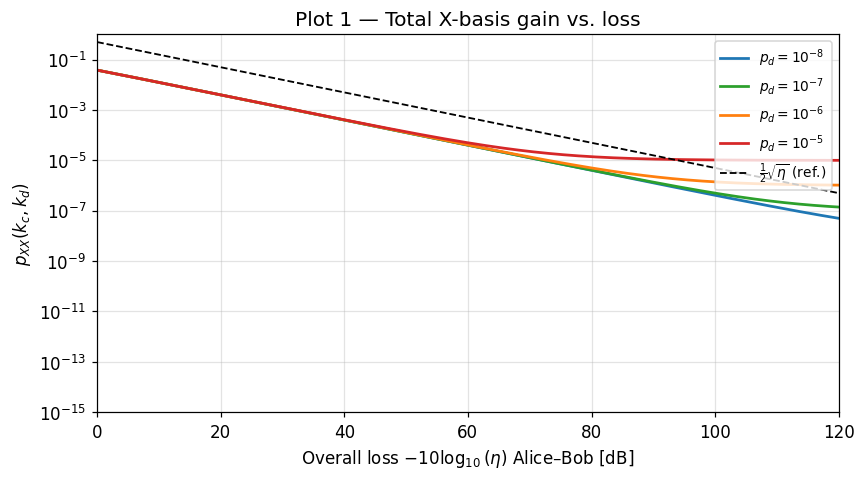

In [ ]:
# ─────────────────────────────────────────────────────────────
# PLOT 1 — Total X-basis gain p_XX vs. loss
#          for multiple dark-count rates
# ─────────────────────────────────────────────────────────────
loss_arr = PARAMS['loss_dB_range']
eta_arr  = dB_to_eta(loss_arr)
alpha    = PARAMS['alpha']
phi      = PARAMS['phi']
theta    = PARAMS['theta']
gamma_arr = np.sqrt(eta_arr) * alpha**2

fig, ax = plt.subplots(figsize=(8, 4.5))

pd_values = [1e-8, 1e-7, 1e-6, 1e-5]
colors    = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

for pd_val, color in zip(pd_values, colors):
    pXX = p_xx_total(phi, theta, gamma_arr, pd_val)
    ax.semilogy(loss_arr, pXX, color=color, label=f'$p_d = 10^{{{int(np.log10(pd_val))}}}$')

# PLOB-like reference: √η / 2  (single-photon from one side)
ax.semilogy(loss_arr, 0.5 * np.sqrt(eta_arr), 'k--', lw=1.2, label='$\\frac{1}{2}\\sqrt{\\eta}$ (ref.)')

ax.set_xlabel('Overall loss $-10\\log_{10}(\\eta)$ Alice–Bob [dB]')
ax.set_ylabel('$p_{XX}(k_c,k_d)$')
ax.set_title('Plot 1 — Total X-basis gain vs. loss')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 120)
ax.set_ylim(1e-15, 1)
plt.tight_layout()
plt.show()

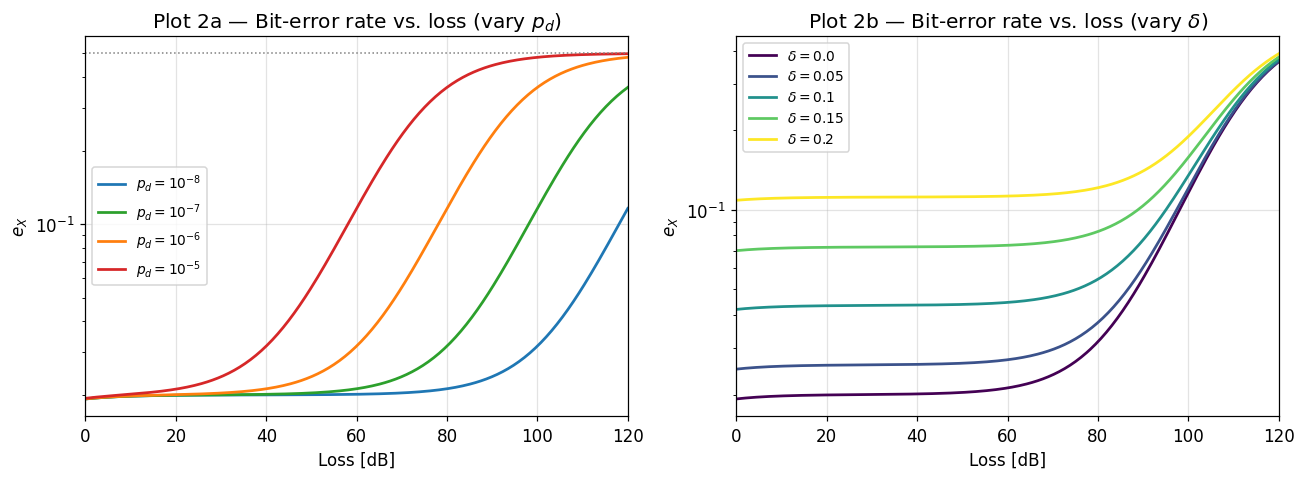

In [ ]:
# ─────────────────────────────────────────────────────────────
# PLOT 2 — X-basis bit-error rate e_X vs. loss
#          for multiple dark-count rates and phase mismatches
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# -- Left panel: varying dark count rate at δ=0 ---------------
ax = axes[0]
for pd_val, color in zip(pd_values, colors):
    eX = bit_error_rate(phi, theta, gamma_arr, pd_val)
    eX = np.clip(eX, 0.0, 0.5)
    ax.semilogy(loss_arr, eX, color=color, label=f'$p_d=10^{{{int(np.log10(pd_val))}}}$')

ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('Loss [dB]')
ax.set_ylabel('$e_X$')
ax.set_title('Plot 2a — Bit-error rate vs. loss (vary $p_d$)')
ax.legend(fontsize=9)
ax.set_xlim(0, 120)

# -- Right panel: varying phase mismatch δ, fixed pd ----------
ax = axes[1]
delta_vals = [0.0, 0.05, 0.10, 0.15, 0.20]
cmap = plt.cm.viridis
for i, dv in enumerate(delta_vals):
    phi_v = dv * np.pi
    eX = bit_error_rate(phi_v, theta, gamma_arr, PARAMS['pd'])
    eX = np.clip(eX, 0.0, 0.5)
    ax.semilogy(loss_arr, eX, color=cmap(i / (len(delta_vals)-1)),
                label=f'$\\delta={dv}$')

ax.set_xlabel('Loss [dB]')
ax.set_ylabel('$e_X$')
ax.set_title('Plot 2b — Bit-error rate vs. loss (vary $\\delta$)')
ax.legend(fontsize=9)
ax.set_xlim(0, 120)

plt.tight_layout()
plt.show()

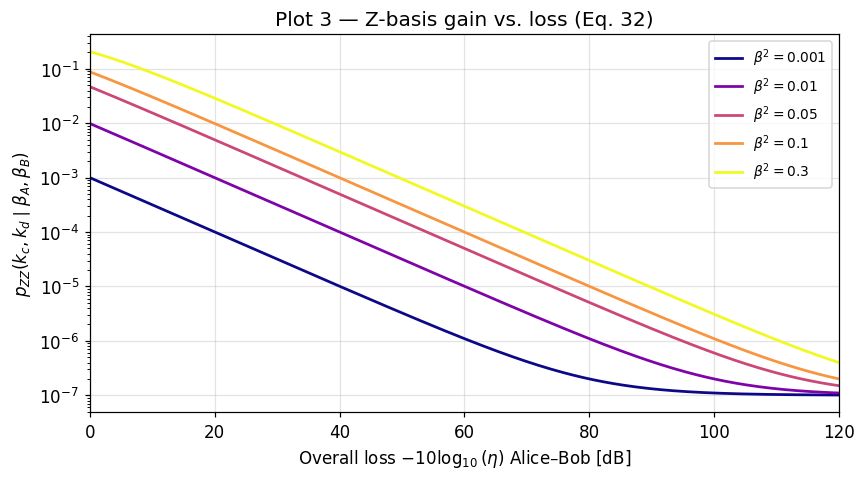

In [ ]:
# ─────────────────────────────────────────────────────────────
# PLOT 3 — Z-basis gain p_ZZ vs. loss
#          for several decoy intensities β²
# ─────────────────────────────────────────────────────────────
beta2_vals = [0.001, 0.01, 0.05, 0.1, 0.3]
fig, ax = plt.subplots(figsize=(8, 4.5))

cmap2 = plt.cm.plasma
for i, b2 in enumerate(beta2_vals):
    beta = np.sqrt(b2)
    pZZ  = p_zz_beta(beta, beta, theta, eta_arr, PARAMS['pd'])
    ax.semilogy(loss_arr, pZZ, color=cmap2(i / (len(beta2_vals)-1)),
                label=f'$\\beta^2={b2}$')

ax.set_xlabel('Overall loss $-10\\log_{10}(\\eta)$ Alice–Bob [dB]')
ax.set_ylabel('$p_{ZZ}(k_c,k_d\\mid\\beta_A,\\beta_B)$')
ax.set_title('Plot 3 — Z-basis gain vs. loss (Eq. 32)')
ax.legend(fontsize=9)
ax.set_xlim(0, 120)
plt.tight_layout()
plt.show()

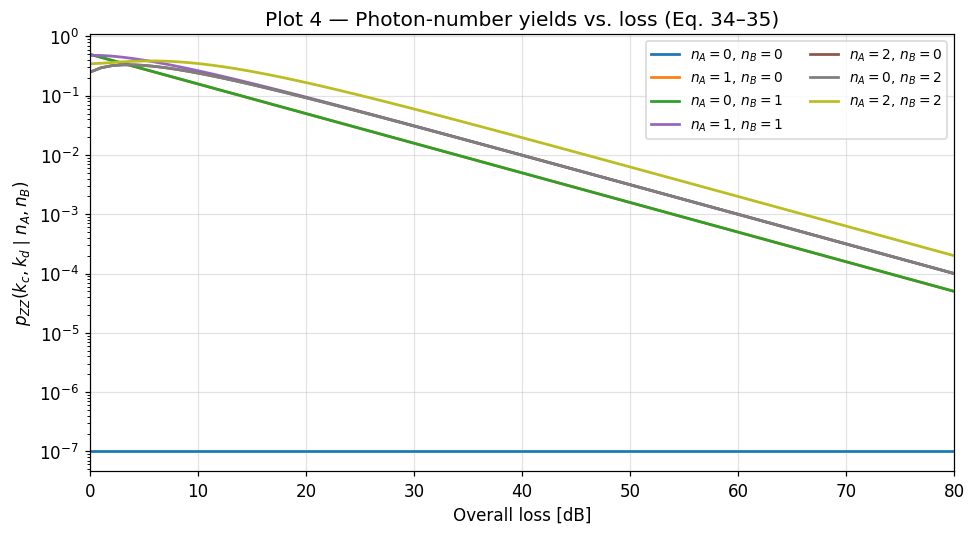


Note: (1,0) and (0,1) yields are equal by symmetry (θ_A=−θ_B here).
Note: (1,0) and (0,1) do NOT contribute to the phase-error rate (paper §4).


In [ ]:
# ─────────────────────────────────────────────────────────────
# PLOT 4 — Photon-number yields p_ZZ(nA, nB | η)
#          as a function of loss for selected (nA, nB) pairs
#
# Only evaluated for small photon numbers (low-loss range)
# as the nested loop in Eq. (35) becomes slow for large nA+nB.
# ─────────────────────────────────────────────────────────────
loss_short = np.linspace(0, 80, 80)   # coarser grid for speed
eta_short  = dB_to_eta(loss_short)

photon_pairs = [(0, 0), (1, 0), (0, 1), (1, 1), (2, 0), (0, 2), (2, 2)]
cmap3 = plt.cm.tab10

fig, ax = plt.subplots(figsize=(9, 5))

for i, (nA, nB) in enumerate(photon_pairs):
    yield_arr = p_zz_photon(nA, nB, thetaA, thetaB, eta_short, PARAMS['pd'])
    ax.semilogy(
        loss_short, yield_arr,
        color=cmap3(i / len(photon_pairs)),
        label=f'$n_A={nA},\\,n_B={nB}$'
    )

ax.set_xlabel('Overall loss [dB]')
ax.set_ylabel('$p_{ZZ}(k_c,k_d\\mid n_A,n_B)$')
ax.set_title('Plot 4 — Photon-number yields vs. loss (Eq. 34–35)')
ax.legend(fontsize=9, ncol=2)
ax.set_xlim(0, 80)
plt.tight_layout()
plt.show()
print('\nNote: (1,0) and (0,1) yields are equal by symmetry (θ_A=−θ_B here).')
print('Note: (1,0) and (0,1) do NOT contribute to the phase-error rate (paper §4).')

In [ ]:
# ─────────────────────────────────────────────────────────────
# PHASE 1 SUMMARY
# ─────────────────────────────────────────────────────────────
print('=' * 60)
print('TF-QKD Phase 1 — Implementation Summary')
print('Author: Anand Ambastha')
print('=' * 60)
print()
print('Functions implemented:')
funcs = [
    ('h(x)',                   'Binary entropy  [safe at 0, 1]'),
    ('omega(φ, θ)',             'Ω = cos φ · cos θ'),
    ('f_plus / f_minus',        'Gain functions f±  (Eq. 29)'),
    ('q_xx',                   'X-basis gain w/o dark counts  (Eq. 28)'),
    ('p_xx_conditional',       'Conditional X-basis gain  (Eq. 27)'),
    ('p_xx_total',             'Total X-basis gain  (Eq. 30)'),
    ('bit_error_rate',         'X-basis BER  (Eq. 31)'),
    ('q_zz',                   'Z-basis gain w/o dark counts  (Eq. 33)'),
    ('p_zz_beta',              'Z-basis gain  (Eq. 32)'),
    ('p_zz_photon',            'Photon-number yield  (Eq. 34)'),
    ('transmission_factor',    'Eq. (35) Helper 1'),
    ('beamsplitter_factor',    'Eq. (35) Helper 2'),
    ('combinatorial_factor',   'Eq. (35) Helper 3'),
    ('polarization_factor',    'Eq. (35) Helper 4'),
    ('interference_term',      'Eq. (35) Helper 5'),
    ('qzz_photon_number',      'Full Eq. (35) assembled from helpers'),
]
for name, desc in funcs:
    print(f'  {name:<28s} {desc}')

print()
print('Phase 2 will add:')
print('  - Finite decoy LP  (Eq. 26)')
print('  - Phase-error upper bound  (Eq. 20–21)')
print('  - Key rate optimisation over α  (Eq. 17–19)')
print('  - Full Fig. 1 reproduction')

TF-QKD Phase 1 — Implementation Summary
Author: Anand Ambastha

Functions implemented:
  h(x)                         Binary entropy  [safe at 0, 1]
  omega(φ, θ)                  Ω = cos φ · cos θ
  f_plus / f_minus             Gain functions f±  (Eq. 29)
  q_xx                         X-basis gain w/o dark counts  (Eq. 28)
  p_xx_conditional             Conditional X-basis gain  (Eq. 27)
  p_xx_total                   Total X-basis gain  (Eq. 30)
  bit_error_rate               X-basis BER  (Eq. 31)
  q_zz                         Z-basis gain w/o dark counts  (Eq. 33)
  p_zz_beta                    Z-basis gain  (Eq. 32)
  p_zz_photon                  Photon-number yield  (Eq. 34)
  transmission_factor          Eq. (35) Helper 1
  beamsplitter_factor          Eq. (35) Helper 2
  combinatorial_factor         Eq. (35) Helper 3
  polarization_factor          Eq. (35) Helper 4
  interference_term            Eq. (35) Helper 5
  qzz_photon_number            Full Eq. (35) assembled from help

---
# TF-QKD Phase 2 — Phase-Error Bound & Preliminary Key Rate
### Curty, Azuma & Lo (2018) · Phase 2 Extension
---

## 13 · Cat States  (Eqs. 12–13)

The X-basis security uses *even* and *odd* cat states:

$$|C_0\rangle = e^{-\alpha^2/2}\sum_{n=0}^\infty \frac{\alpha^{2n}}{\sqrt{(2n)!}}|2n\rangle
=: \sum_n c^{(0)}_n |n\rangle \tag{12}$$

$$|C_1\rangle = e^{-\alpha^2/2}\sum_{n=0}^\infty \frac{\alpha^{2n+1}}{\sqrt{(2n+1)!}}|2n+1\rangle
=: \sum_n c^{(1)}_n |n\rangle \tag{13}$$

Key property: $c^{(0)}_{2m+1} = c^{(1)}_{2m} = 0$ for all $m$ — even cat state has only even
photon components; odd cat state has only odd photon components.
This is why $(n_A, n_B) \in \{(0,1),(1,0)\}$ never contribute to the phase-error rate.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Additional imports for Phase 2
# ─────────────────────────────────────────────────────────────
from scipy.special import gammaln   # log-gamma for stable factorial
from functools import lru_cache

# ── Performance flag ──────────────────────────────────────────
FAST_MODE = True   # reduced Nmax and sweep resolution

if FAST_MODE:
    NMAX_DEFAULT  = 4     # paper: Nmax=4 already near-optimal (Fig. 5)
    LOSS_SWEEP    = np.linspace(0, 120, 60)   # coarser for speed
    NMAX_CONV_VALS = [0, 2, 4, 6, 8]          # for convergence plot
else:
    NMAX_DEFAULT  = 8
    LOSS_SWEEP    = np.linspace(0, 120, 200)
    NMAX_CONV_VALS = [0, 2, 4, 6, 8, 10, 12]

print(f'FAST_MODE={FAST_MODE}, Nmax={NMAX_DEFAULT}, sweep pts={len(LOSS_SWEEP)}')

FAST_MODE=True, Nmax=4, sweep pts=60


In [ ]:
# ─────────────────────────────────────────────────────────────
# Cat-state coefficients  (Eqs. 12–13)
# Numerically stable via log-space arithmetic (gammaln).
#
# c_even(n, α)  =  exp(−α²/2) · α^(2n) / sqrt((2n)!)
#                              n = 0,1,2,...  (Fock index for |2n⟩)
# c_odd(n, α)   =  exp(−α²/2) · α^(2n+1) / sqrt((2n+1)!)
#                              n = 0,1,2,...  (Fock index for |2n+1⟩)
# Returns 0.0 for invalid arguments.
# ─────────────────────────────────────────────────────────────

def c_even(n: int, alpha: float) -> float:
    """Coefficient c^(0)_{2n} of |2n⟩ in the even cat state |C_0⟩ (Eq. 12).

    c_even(n, α) = exp(−α²/2) · α^(2n) / sqrt((2n)!)

    Parameters
    ----------
    n     : int   — non-negative integer (Fock sub-index)
    alpha : float — coherent amplitude α > 0

    Returns
    -------
    float — non-negative coefficient; 0.0 if n < 0 or alpha <= 0.
    """
    if n < 0 or alpha <= 0.0:
        return 0.0
    photon_number = 2 * n
    # log c = -α²/2 + 2n·log(α) - 0.5·log((2n)!)
    log_c = (
        -0.5 * alpha**2
        + photon_number * np.log(alpha)
        - 0.5 * gammaln(photon_number + 1)   # log((2n)!)
    )
    return float(np.exp(log_c))


def c_odd(n: int, alpha: float) -> float:
    """Coefficient c^(1)_{2n+1} of |2n+1⟩ in the odd cat state |C_1⟩ (Eq. 13).

    c_odd(n, α) = exp(−α²/2) · α^(2n+1) / sqrt((2n+1)!)

    Parameters
    ----------
    n     : int   — non-negative integer (Fock sub-index)
    alpha : float — coherent amplitude α > 0

    Returns
    -------
    float — non-negative coefficient; 0.0 if n < 0 or alpha <= 0.
    """
    if n < 0 or alpha <= 0.0:
        return 0.0
    photon_number = 2 * n + 1
    # log c = -α²/2 + (2n+1)·log(α) - 0.5·log((2n+1)!)
    log_c = (
        -0.5 * alpha**2
        + photon_number * np.log(alpha)
        - 0.5 * gammaln(photon_number + 1)   # log((2n+1)!)
    )
    return float(np.exp(log_c))


def get_coeff(j: int, m: int, alpha: float) -> float:
    """Return c^(j)_{2m+j} for j in {0,1}.

    Dispatches to c_even (j=0) or c_odd (j=1).
    Returns 0 for j not in {0,1}.
    """
    if j == 0:
        return c_even(m, alpha)
    elif j == 1:
        return c_odd(m, alpha)
    return 0.0


# ── Quick tests ───────────────────────────────────────────────
alpha_test = PARAMS['alpha']
print(f'c_even(0, {alpha_test}) = {c_even(0, alpha_test):.6e}   [Fock |0⟩ in even cat]')
print(f'c_even(1, {alpha_test}) = {c_even(1, alpha_test):.6e}   [Fock |2⟩ in even cat]')
print(f'c_odd(0,  {alpha_test}) = {c_odd(0,  alpha_test):.6e}   [Fock |1⟩ in odd cat]')
print(f'c_odd(1,  {alpha_test}) = {c_odd(1,  alpha_test):.6e}   [Fock |3⟩ in odd cat]')
print(f'c_even(-1,{alpha_test}) = {c_even(-1, alpha_test):.6e}  [invalid → 0]')
print('Cat-state coefficient functions defined.')

c_even(0, 0.2) = 9.801987e-01   [Fock |0⟩ in even cat]
c_even(1, 0.2) = 2.772421e-02   [Fock |2⟩ in even cat]
c_odd(0,  0.2) = 1.960397e-01   [Fock |1⟩ in odd cat]
c_odd(1,  0.2) = 3.201315e-03   [Fock |3⟩ in odd cat]
c_even(-1,0.2) = 0.000000e+00  [invalid → 0]
Cat-state coefficient functions defined.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Normalization validation: sum |c_j|^2 = 1
#
# |C_0⟩ and |C_1⟩ are NOT normalized to 1 in general;
# they are unnormalized amplitudes.  The paper (Eq. 12-13)
# defines them as components of a normalized state via
# |ψ_X⟩ = (|+⟩|C_0⟩ + |−⟩|C_1⟩)/√2, so each cat state
# individually satisfies ⟨C_j|C_j⟩ = 1 only in the limit α→∞.
# In practice, for finite truncation:
# sum_{n=0}^{N} |c_even(n)|^2 → (1 + e^{-2α²})/2  as N→∞
# sum_{n=0}^{N} |c_odd(n)|^2  → (1 - e^{-2α²})/2  as N→∞
# The sum of both = 1 (total probability).
# ─────────────────────────────────────────────────────────────

def norm_even(alpha: float, Nterms: int = 60) -> float:
    """sum_{n=0}^{Nterms-1} |c_even(n, alpha)|^2."""
    return sum(c_even(n, alpha)**2 for n in range(Nterms))

def norm_odd(alpha: float, Nterms: int = 60) -> float:
    """sum_{n=0}^{Nterms-1} |c_odd(n, alpha)|^2."""
    return sum(c_odd(n, alpha)**2 for n in range(Nterms))

alpha_test = PARAMS['alpha']
Ncheck = 50

ne = norm_even(alpha_test, Ncheck)
no = norm_odd(alpha_test, Ncheck)
total = ne + no

# Analytic reference values
ref_even = 0.5 * (1.0 + np.exp(-2.0 * alpha_test**2))
ref_odd  = 0.5 * (1.0 - np.exp(-2.0 * alpha_test**2))

print(f'α = {alpha_test}')
print(f'  sum |c_even|² (N={Ncheck}) = {ne:.10f}  [analytic: {ref_even:.10f}]')
print(f'  sum |c_odd |² (N={Ncheck}) = {no:.10f}  [analytic: {ref_odd:.10f}]')
print(f'  total = {total:.12f}  [should be ≈ 1.0]')
print()

# Normalization checks
print(f'  |norm_even - analytic| = {abs(ne - ref_even):.2e}')
print(f'  |norm_odd  - analytic| = {abs(no - ref_odd ):.2e}')
print(f'  |total     - 1.0      | = {abs(total - 1.0):.2e}')

ok_even  = abs(ne    - ref_even) < 1e-10
ok_odd   = abs(no    - ref_odd ) < 1e-10
ok_total = abs(total - 1.0     ) < 1e-10
print(f'  even OK={ok_even}, odd OK={ok_odd}, total OK={ok_total}')

α = 0.2
  sum |c_even|² (N=50) = 0.9615581732  [analytic: 0.9615581732]
  sum |c_odd |² (N=50) = 0.0384418268  [analytic: 0.0384418268]
  total = 1.000000000000  [should be ≈ 1.0]

  |norm_even - analytic| = 1.11e-16
  |norm_odd  - analytic| = 6.94e-18
  |total     - 1.0      | = 2.22e-16
  even OK=True, odd OK=True, total OK=True


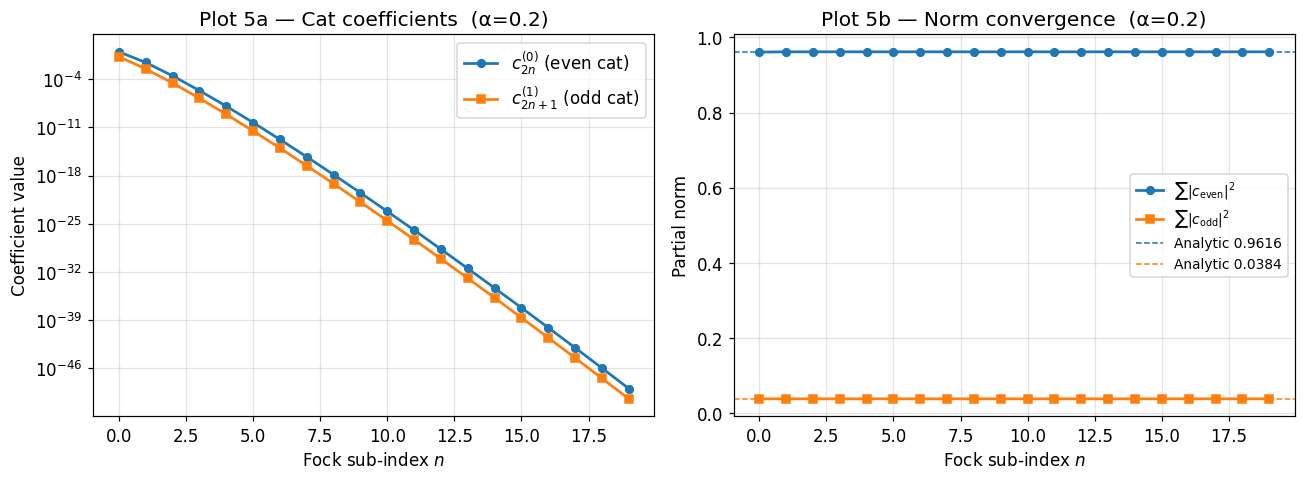

In [ ]:
# ─────────────────────────────────────────────────────────────
# PLOT 5 — Cat-coefficient decay and normalization convergence
# ─────────────────────────────────────────────────────────────
Nterms  = 20
ns      = np.arange(Nterms)
alpha_p = PARAMS['alpha']

c_ev_arr = np.array([c_even(n, alpha_p) for n in ns])
c_od_arr = np.array([c_odd(n,  alpha_p) for n in ns])

# Partial norm sums for convergence
norm_ev_cum = np.cumsum(c_ev_arr**2)
norm_od_cum = np.cumsum(c_od_arr**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: coefficient values
ax = axes[0]
ax.semilogy(ns, c_ev_arr, 'o-', label='$c^{(0)}_{2n}$ (even cat)', ms=5)
ax.semilogy(ns, c_od_arr, 's-', label='$c^{(1)}_{2n+1}$ (odd cat)',  ms=5)
ax.set_xlabel('Fock sub-index $n$')
ax.set_ylabel('Coefficient value')
ax.set_title(f'Plot 5a — Cat coefficients  (α={alpha_p})')
ax.legend()

# Right: cumulative norm
ax = axes[1]
ref_e = 0.5 * (1.0 + np.exp(-2.0 * alpha_p**2))
ref_o = 0.5 * (1.0 - np.exp(-2.0 * alpha_p**2))
ax.plot(ns, norm_ev_cum, 'o-', label='$\\sum|c_\\mathrm{even}|^2$', ms=5)
ax.plot(ns, norm_od_cum, 's-', label='$\\sum|c_\\mathrm{odd}|^2$',  ms=5)
ax.axhline(ref_e, color='C0', ls='--', lw=1, label=f'Analytic {ref_e:.4f}')
ax.axhline(ref_o, color='C1', ls='--', lw=1, label=f'Analytic {ref_o:.4f}')
ax.set_xlabel('Fock sub-index $n$')
ax.set_ylabel('Partial norm')
ax.set_title(f'Plot 5b — Norm convergence  (α={alpha_p})')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 14 · Phase-Error Estimation  (Eqs. 20–22)

### Eq. (20) — exact phase-error upper bound
$$e^{\mathrm{upp}}_{Z,k_ck_d} = \frac{1}{p_{XX}(k_c,k_d)}\sum_{j=0,1}
\left[\sum_{m_A,m_B=0}^{\infty} c^{(j)}_{2m_A+j}\,c^{(j)}_{2m_B+j}
\sqrt{p_{ZZ}(k_c,k_d\mid 2m_A+j,\,2m_B+j)}\right]^2 \tag{20}$$

### Eq. (21) — finite-truncation upper bound
Replace the exact sum with a sum over $(m_A,m_B)\in S_j$ plus a residual $\Delta_j$:
$$e^{\mathrm{upp}}_{Z,k_ck_d} \leq \frac{1}{p_{XX}(k_c,k_d)}\sum_{j=0,1}
\left[\sum_{(m_A,m_B)\in S_j} c^{(j)}_{2m_A+j}\,c^{(j)}_{2m_B+j}
\sqrt{p^{\mathrm{upp}}_{ZZ}} + \Delta_j\right]^2 \tag{21}$$

where $S_j = \{(m_A,m_B): 2m_A+j+2m_B+j \leq N_{\max}\}$.

### Eq. (22) — residual term
$$\Delta_j = \sum_{(m_A,m_B)\notin S_j} c^{(j)}_{2m_A+j}\,c^{(j)}_{2m_B+j} \tag{22}$$

In [ ]:
# ─────────────────────────────────────────────────────────────
# Eq. (21) inner sum for one j ∈ {0, 1}
#
# inner_j = sum_{(mA,mB) in Sj} c_j(2mA+j) * c_j(2mB+j)
#                               * sqrt(pZZ(kc,kd | 2mA+j, 2mB+j))
#
# Uses p_zz_photon from Phase 1 (infinite-decoy / exact yields).
# ─────────────────────────────────────────────────────────────

def inner_sum_j(
    j:      int,
    alpha:  float,
    eta:    float,
    pd:     float,
    thetaA: float,
    thetaB: float,
    Nmax:   int,
) -> float:
    """Inner sum S_j(α, η) for the phase-error bound — Eq. (21).

    Sums over (mA, mB) with 2mA+j + 2mB+j ≤ Nmax  (even-parity constraint).

    Parameters
    ----------
    j              : int   — cat parity index (0 = even, 1 = odd)
    alpha          : float — signal amplitude
    eta            : float — single scalar transmittance
    pd             : float — dark-count probability
    thetaA, thetaB : float — polarisation angles [rad]
    Nmax           : int   — photon truncation (even number)

    Returns
    -------
    float — value of the inner sum.
    """
    eta_arr = np.array([eta], dtype=np.float64)
    total   = 0.0

    # Maximum sub-index mA or mB (photon n = 2m+j ≤ Nmax → m ≤ (Nmax-j)//2)
    m_max = (Nmax - j) // 2
    if m_max < 0:
        return 0.0

    for mA in range(m_max + 1):
        cA = get_coeff(j, mA, alpha)
        if cA == 0.0:
            continue
        nA = 2 * mA + j

        for mB in range(m_max + 1):
            # Enforce 2mA+j + 2mB+j ≤ Nmax
            if nA + (2 * mB + j) > Nmax:
                continue

            cB = get_coeff(j, mB, alpha)
            if cB == 0.0:
                continue
            nB = 2 * mB + j

            # Yield p_ZZ(kc,kd | nA, nB) — from Phase 1 exact formula
            pzz = float(p_zz_photon(nA, nB, thetaA, thetaB, eta_arr, pd)[0])
            pzz = max(pzz, 0.0)   # guard against tiny negatives

            total += cA * cB * np.sqrt(pzz)

    return total


# Quick smoke test
_test_eta = dB_to_eta(20.0)
_s0 = inner_sum_j(0, PARAMS['alpha'], _test_eta, PARAMS['pd'],
                   PARAMS['thetaA'], PARAMS['thetaB'], Nmax=4)
_s1 = inner_sum_j(1, PARAMS['alpha'], _test_eta, PARAMS['pd'],
                   PARAMS['thetaA'], PARAMS['thetaB'], Nmax=4)
print(f'inner_sum_j(j=0, loss=20dB, Nmax=4) = {_s0:.6e}')
print(f'inner_sum_j(j=1, loss=20dB, Nmax=4) = {_s1:.6e}')

inner_sum_j(j=0, loss=20dB, Nmax=4) = 1.739751e-02
inner_sum_j(j=1, loss=20dB, Nmax=4) = 1.234249e-02


In [ ]:
# ─────────────────────────────────────────────────────────────
# Eq. (22) — Residual terms Δ_j
#
# Δ_j = sum_{(mA,mB) NOT in Sj} c_j(2mA+j) · c_j(2mB+j)
#      = [sum_{m=0}^∞ c_j(2m+j)]^2  −  [sum_{m in Sj} c_j(2m+j)]^2
#
# Since pZZ ≤ 1, this bounds the contribution from excluded terms.
# Residuals should decrease monotonically as Nmax increases.
# ─────────────────────────────────────────────────────────────

def marginal_coeff_sum(j: int, alpha: float, Nterms: int = 80) -> float:
    """Sum_{n=0}^{Nterms-1} c^(j)_{2n+j}  (unnormalized partial sum)."""
    return sum(get_coeff(j, n, alpha) for n in range(Nterms))


def truncated_coeff_sum(j: int, alpha: float, Nmax: int) -> float:
    """Sum of c^(j)_{2m+j} over m with 2m+j ≤ Nmax."""
    m_max = (Nmax - j) // 2
    if m_max < 0:
        return 0.0
    return sum(get_coeff(j, m, alpha) for m in range(m_max + 1))


def residual_j(j: int, alpha: float, Nmax: int, Nterms: int = 80) -> float:
    """Residual Δ_j — Eq. (22).

    Δ_j = [total_j]^2 - [truncated_j]^2

    where total_j   = sum_{m≥0} c^(j)_{2m+j}
          truncated = sum over (mA,mB) in Sj of c_j(2mA+j)·c_j(2mB+j)
                    ≈ [sum_{m in Sj} c_j(2m+j)]^2   (separable approx)

    Parameters
    ----------
    j      : int — 0 or 1
    alpha  : float — signal amplitude
    Nmax   : int — truncation parameter
    Nterms : int — terms used to approximate the full sum

    Returns
    -------
    float — residual ≥ 0.
    """
    S_full  = marginal_coeff_sum(j, alpha, Nterms)
    S_trunc = truncated_coeff_sum(j, alpha, Nmax)
    residual = S_full**2 - S_trunc**2
    return max(residual, 0.0)   # guard tiny negatives from truncation


# Convenience wrappers matching prompt naming
def residual_even(alpha: float, Nmax: int) -> float:
    """Δ_0  — residual for the even cat state."""
    return residual_j(0, alpha, Nmax)

def residual_odd(alpha: float, Nmax: int) -> float:
    """Δ_1  — residual for the odd cat state."""
    return residual_j(1, alpha, Nmax)


# Sanity: residuals decrease with Nmax
alpha_p = PARAMS['alpha']
print('Residuals vs Nmax:')
for Nm in [0, 2, 4, 6, 8, 10]:
    d0 = residual_even(alpha_p, Nm)
    d1 = residual_odd(alpha_p, Nm)
    print(f'  Nmax={Nm:2d}   Δ_0={d0:.4e}   Δ_1={d1:.4e}')

Residuals vs Nmax:
  Nmax= 0   Δ_0=5.5769e-02   Δ_1=3.9708e-02
  Nmax= 2   Δ_0=6.5018e-04   Δ_1=1.2769e-03
  Nmax= 4   Δ_0=4.7397e-06   Δ_1=1.1481e-05
  Nmax= 6   Δ_0=2.5306e-08   Δ_1=7.0767e-08
  Nmax= 8   Δ_0=1.0662e-10   Δ_1=3.3330e-10
  Nmax=10   Δ_0=3.7126e-13   Δ_1=1.2704e-12


In [ ]:
# ─────────────────────────────────────────────────────────────
# Phase-error upper bound  — Eq. (20) / Eq. (21)
#
# eZ_upper(kc, kd) =
#   (1/pXX) * sum_{j=0,1} [inner_sum_j + Delta_j]^2
#
# We use the exact pZZ yields (infinite-decoy assumption),
# so p_upp_ZZ = p_ZZ exactly for (mA,mB) in Sj,
# and excluded pairs contribute via Delta_j.
# ─────────────────────────────────────────────────────────────

def phase_error_upper_bound(
    alpha:  float,
    eta:    float,
    pd:     float,
    thetaA: float,
    thetaB: float,
    Nmax:   int,
    kc:     int = 1,
    kd:     int = 0,
) -> float:
    """Upper bound on phase-error rate e_Z — Eqs. (20–21).

    Parameters
    ----------
    alpha          : float — X-basis signal amplitude
    eta            : float — total transmittance (single scalar)
    pd             : float — dark-count probability
    thetaA, thetaB : float — polarisation angles [rad]
    Nmax           : int   — photon truncation (even)
    kc, kd         : int   — detector pattern (default (1,0))

    Returns
    -------
    float — e_Z_upper ∈ [0, 1], clipped at 0.5.
    """
    phi   = PARAMS['phi']    # phase mismatch
    theta = thetaA - thetaB  # composite polarisation angle

    # Total X-basis gain  p_XX(kc, kd) — scalar
    gamma = np.sqrt(eta) * alpha**2
    pXX   = float(p_xx_total(phi, theta, np.array([gamma]), pd)[0])

    if pXX <= 0.0:
        return 0.5   # no events → undefined; worst case

    # Sum over j = 0, 1
    eZ_numerator = 0.0
    for j in range(2):
        # Inner sum over (mA, mB) in Sj
        S_j = inner_sum_j(j, alpha, eta, pd, thetaA, thetaB, Nmax)

        # Residual from excluded (mA, mB) pairs
        D_j = residual_j(j, alpha, Nmax)

        eZ_numerator += (S_j + D_j) ** 2

    eZ = eZ_numerator / pXX
    return float(np.clip(eZ, 0.0, 0.5))


# Smoke test
_eta20 = float(dB_to_eta(20.0))
_eZ    = phase_error_upper_bound(
    PARAMS['alpha'], _eta20, PARAMS['pd'],
    PARAMS['thetaA'], PARAMS['thetaB'],
    Nmax=NMAX_DEFAULT,
)
print(f'eZ_upper at 20 dB loss, Nmax={NMAX_DEFAULT}: {_eZ:.6f}')
print('phase_error_upper_bound defined.')

eZ_upper at 20 dB loss, Nmax=4: 0.114336
phase_error_upper_bound defined.


## 15 · Truncation Framework

Sweep $N_{\max}$ to demonstrate convergence of the phase-error bound.
As shown in Fig. 5 of the paper, $N_{\max} = 4$ already delivers a key rate
very close to the $N_{\max} = \infty$ limit.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Convergence of eZ_upper vs Nmax at a fixed loss point
# ─────────────────────────────────────────────────────────────
loss_fixed = 40.0   # dB — mid-range diagnostic point
eta_fixed  = float(dB_to_eta(loss_fixed))
alpha_p    = PARAMS['alpha']
pd_p       = PARAMS['pd']
tA, tB     = PARAMS['thetaA'], PARAMS['thetaB']

nmax_vals  = list(range(0, 13, 2))   # 0,2,4,...,12
eZ_vs_Nmax = []
D0_vs_Nmax = []
D1_vs_Nmax = []

for Nm in nmax_vals:
    eZ = phase_error_upper_bound(alpha_p, eta_fixed, pd_p, tA, tB, Nm)
    d0 = residual_even(alpha_p, Nm)
    d1 = residual_odd( alpha_p, Nm)
    eZ_vs_Nmax.append(eZ)
    D0_vs_Nmax.append(d0)
    D1_vs_Nmax.append(d1)
    print(f'  Nmax={Nm:2d}  eZ={eZ:.6f}  Δ0={d0:.3e}  Δ1={d1:.3e}')

print(f'\nConvergence at {loss_fixed} dB loss: eZ changes by',
      f'{abs(eZ_vs_Nmax[-1]-eZ_vs_Nmax[-2]):.2e} from Nmax=10 to 12')

  Nmax= 0  eZ=0.500000  Δ0=5.577e-02  Δ1=3.971e-02
  Nmax= 2  eZ=0.166709  Δ0=6.502e-04  Δ1=1.277e-03
  Nmax= 4  eZ=0.128010  Δ0=4.740e-06  Δ1=1.148e-05
  Nmax= 6  eZ=0.127827  Δ0=2.531e-08  Δ1=7.077e-08
  Nmax= 8  eZ=0.127827  Δ0=1.066e-10  Δ1=3.333e-10
  Nmax=10  eZ=0.127828  Δ0=3.713e-13  Δ1=1.270e-12
  Nmax=12  eZ=0.127828  Δ0=8.882e-16  Δ1=4.066e-15

Convergence at 40.0 dB loss: eZ changes by 1.60e-10 from Nmax=10 to 12


## 16 · Preliminary Key Rate  (Eqs. 17–19)

$$R^{\mathrm{low}}_{X,k_ck_d} = p_{XX}(k_c,k_d)\left[1 - h(e_{X,k_ck_d})
- h\!\left(\min\!\left\{\tfrac{1}{2},\,e^{\mathrm{upp}}_{Z,k_ck_d}\right\}\right)\right]$$

$$R^{\mathrm{low}}_X = \max(R^{\mathrm{low}}_{X,10},0) + \max(R^{\mathrm{low}}_{X,01},0)$$

Assumptions here:
- Infinite-decoy (asymptotic): $p^{\mathrm{upp}}_{ZZ} = p_{ZZ}$ exactly.
- Fixed $\alpha$ (no optimisation over $\alpha$ in this phase).
- Symmetric channels: $(k_c,k_d)=(1,0)$ and $(0,1)$ contribute equally.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Preliminary key rate — Eq. (18–19)
# ─────────────────────────────────────────────────────────────

def key_rate_single(
    alpha:  float,
    eta:    float,
    pd:     float,
    thetaA: float,
    thetaB: float,
    Nmax:   int,
    kc:     int = 1,
    kd:     int = 0,
) -> float:
    """Key rate contribution from one detector pattern (kc, kd).

    R_low_X_{kckd} = pXX * [1 - h(eX) - h(min(0.5, eZ_upper))]

    Returns max(R, 0).
    """
    phi   = PARAMS['phi']
    theta = thetaA - thetaB
    gamma = np.sqrt(eta) * alpha**2

    # X-basis gain and bit-error rate
    pXX = float(p_xx_total(phi, theta, np.array([gamma]), pd)[0])
    eX  = float(bit_error_rate(phi, theta, np.array([gamma]), pd)[0])
    eX  = float(np.clip(eX, 0.0, 0.5))

    # Phase-error upper bound
    eZ  = phase_error_upper_bound(alpha, eta, pd, thetaA, thetaB, Nmax, kc, kd)
    eZ  = min(eZ, 0.5)

    rate = pXX * (1.0 - h(eX) - h(eZ))
    return max(rate, 0.0)


def key_rate(
    alpha:  float,
    eta:    float,
    pd:     float,
    thetaA: float,
    thetaB: float,
    Nmax:   int,
) -> float:
    """Total key rate R_low_X = R_10 + R_01 — Eqs. (17–18).

    By symmetry under kc↔kd for the channel model used,
    R_10 = R_01, so we compute both and sum.

    Parameters
    ----------
    alpha          : float
    eta            : float — total transmittance
    pd             : float
    thetaA, thetaB : float
    Nmax           : int

    Returns
    -------
    float — key rate ≥ 0 (per pulse).
    """
    R10 = key_rate_single(alpha, eta, pd, thetaA, thetaB, Nmax, kc=1, kd=0)
    R01 = key_rate_single(alpha, eta, pd, thetaA, thetaB, Nmax, kc=0, kd=1)
    return R10 + R01


# Smoke test
_R = key_rate(PARAMS['alpha'], _eta20, PARAMS['pd'],
              PARAMS['thetaA'], PARAMS['thetaB'], Nmax=NMAX_DEFAULT)
print(f'Key rate at 20 dB loss, Nmax={NMAX_DEFAULT}: {_R:.4e}')
print('key_rate functions defined.')

Key rate at 20 dB loss, Nmax=4: 2.7570e-03
key_rate functions defined.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Key rate vs loss sweep
# ─────────────────────────────────────────────────────────────
print(f'Computing key rate sweep ({len(LOSS_SWEEP)} points, Nmax={NMAX_DEFAULT})...')

alpha_p = PARAMS['alpha']
pd_p    = PARAMS['pd']
tA, tB  = PARAMS['thetaA'], PARAMS['thetaB']

R_arr = np.zeros(len(LOSS_SWEEP))
for i, loss_dB in enumerate(LOSS_SWEEP):
    eta_i = float(dB_to_eta(loss_dB))
    R_arr[i] = key_rate(alpha_p, eta_i, pd_p, tA, tB, NMAX_DEFAULT)

# PLOB bound:  -log2(1 - eta)
eta_sweep = dB_to_eta(LOSS_SWEEP)
PLOB      = -np.log2(1.0 - eta_sweep)

# Save for convergence plot in §17
_R_Nmax_default = R_arr.copy()

print('Sweep done.')
# Report a few values
for loss_check in [10, 20, 40, 60, 80]:
    idx = np.argmin(np.abs(LOSS_SWEEP - loss_check))
    print(f'  loss={loss_check:3d} dB  R={R_arr[idx]:.3e}')

Computing key rate sweep (60 points, Nmax=4)...
Sweep done.
  loss= 10 dB  R=9.886e-03
  loss= 20 dB  R=2.643e-03
  loss= 40 dB  R=2.254e-04
  loss= 60 dB  R=1.689e-05
  loss= 80 dB  R=3.236e-07


## 17 · Convergence Diagnostics

Four plots:
1. $e_Z$ vs $N_{\max}$
2. Residual terms $\Delta_j$ vs $N_{\max}$
3. Cat-coefficient decay (cross-check Section 13)
4. Preliminary key rate vs loss for several $N_{\max}$ values

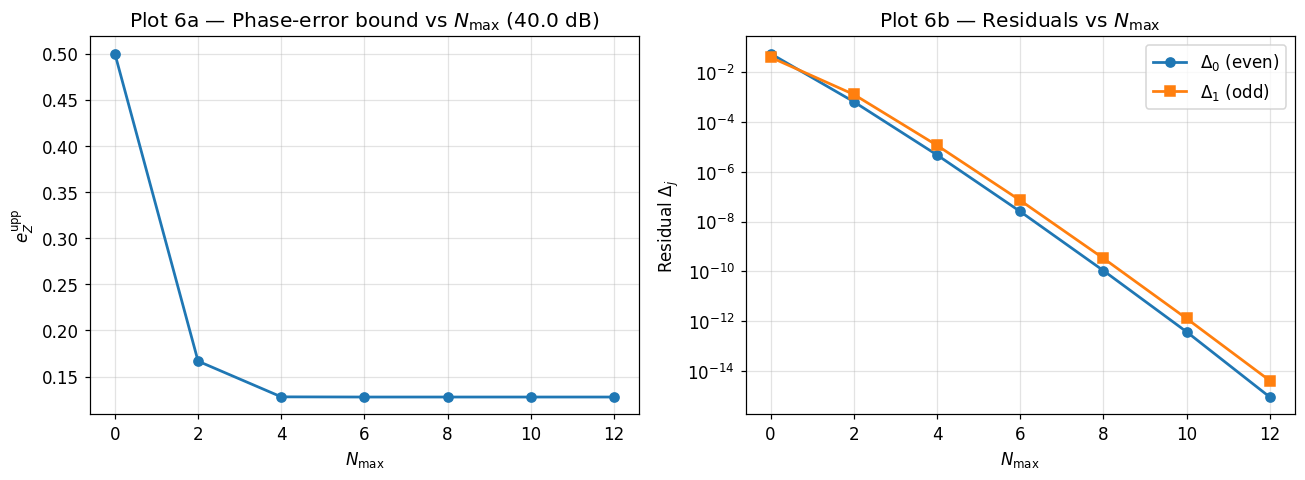

In [ ]:
# ─────────────────────────────────────────────────────────────
# PLOT 6 — eZ vs Nmax   (left)   |   Residuals vs Nmax  (right)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(nmax_vals, eZ_vs_Nmax, 'o-', ms=6)
ax.set_xlabel('$N_{\\max}$')
ax.set_ylabel('$e^{\\mathrm{upp}}_Z$')
ax.set_title(f'Plot 6a — Phase-error bound vs $N_{{\\max}}$ ({loss_fixed} dB)')
ax.set_xticks(nmax_vals)

ax = axes[1]
ax.semilogy(nmax_vals, [max(v, 1e-16) for v in D0_vs_Nmax], 'o-', ms=6, label='$\\Delta_0$ (even)')
ax.semilogy(nmax_vals, [max(v, 1e-16) for v in D1_vs_Nmax], 's-', ms=6, label='$\\Delta_1$ (odd)')
ax.set_xlabel('$N_{\\max}$')
ax.set_ylabel('Residual $\\Delta_j$')
ax.set_title('Plot 6b — Residuals vs $N_{\\max}$')
ax.set_xticks(nmax_vals)
ax.legend()

plt.tight_layout()
plt.show()

Computing Nmax convergence sweep (5 values)...


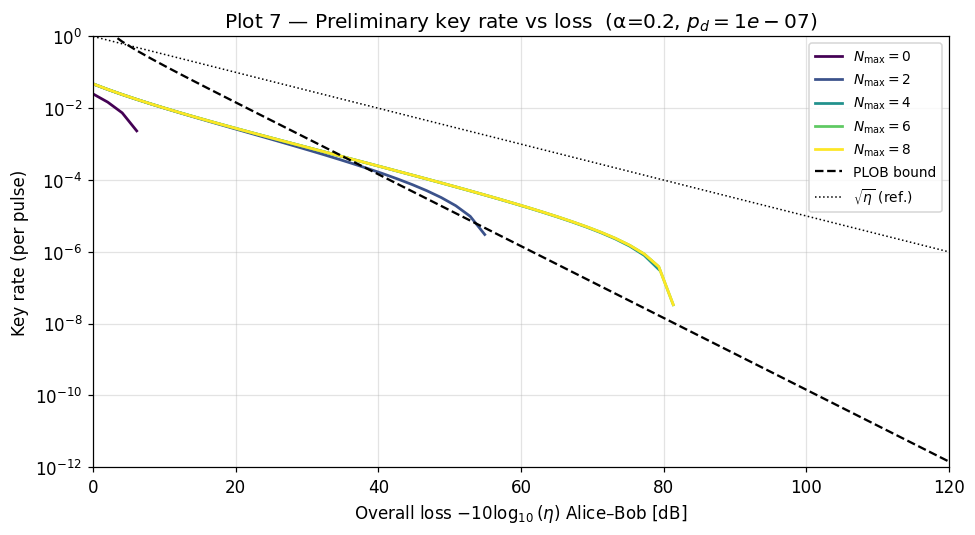

Done.


In [ ]:
# ─────────────────────────────────────────────────────────────
# PLOT 7 — Key rate vs loss for several Nmax values
# ─────────────────────────────────────────────────────────────
print(f'Computing Nmax convergence sweep ({len(NMAX_CONV_VALS)} values)...')

alpha_p = PARAMS['alpha']
pd_p    = PARAMS['pd']
tA, tB  = PARAMS['thetaA'], PARAMS['thetaB']

fig, ax = plt.subplots(figsize=(9, 5))
cmap_r = plt.cm.viridis

for i_nm, Nm in enumerate(NMAX_CONV_VALS):
    R_nm = np.zeros(len(LOSS_SWEEP))
    for i, loss_dB in enumerate(LOSS_SWEEP):
        eta_i = float(dB_to_eta(loss_dB))
        R_nm[i] = key_rate(alpha_p, eta_i, pd_p, tA, tB, Nm)

    pos_mask = R_nm > 0
    color = cmap_r(i_nm / max(len(NMAX_CONV_VALS) - 1, 1))
    label = f'$N_{{\\max}}={Nm}$'
    if np.any(pos_mask):
        ax.semilogy(LOSS_SWEEP[pos_mask], R_nm[pos_mask], color=color, label=label)

# PLOB bound
ax.semilogy(LOSS_SWEEP, PLOB, 'k--', lw=1.5, label='PLOB bound')

# √η reference
ax.semilogy(LOSS_SWEEP, np.sqrt(eta_sweep), 'k:', lw=1.0, label='$\\sqrt{\\eta}$ (ref.)')

ax.set_xlabel('Overall loss $-10\\log_{10}(\\eta)$ Alice–Bob [dB]')
ax.set_ylabel('Key rate (per pulse)')
ax.set_title(f'Plot 7 — Preliminary key rate vs loss  (α={alpha_p}, $p_d={pd_p:.0e}$)')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 120)
ax.set_ylim(1e-12, 1)
plt.tight_layout()
plt.show()
print('Done.')

In [ ]:
# ─────────────────────────────────────────────────────────────
# VALIDATION CHECKS — Phase 2
# ─────────────────────────────────────────────────────────────
p2_errors = []

def check2(condition: bool, label: str) -> None:
    status = ' PASS' if condition else '✗ FAIL'
    print(f'  [{status}]  {label}')
    if not condition:
        p2_errors.append(label)

alpha_p = PARAMS['alpha']
pd_p    = PARAMS['pd']
tA, tB  = PARAMS['thetaA'], PARAMS['thetaB']

print('=== Phase 2 Validation Checks ===')
print()

print('--- Cat-coefficient decay ---')
# Coefficients must decrease to zero for large n
c_ev_large = c_even(30, alpha_p)
c_od_large = c_odd(30, alpha_p)
check2(c_ev_large < 1e-10, f'c_even(30, α={alpha_p}) decays < 1e-10 [{c_ev_large:.2e}]')
check2(c_od_large < 1e-10, f'c_odd(30,  α={alpha_p}) decays < 1e-10 [{c_od_large:.2e}]')
# Non-negativity
check2(all(c_even(n, alpha_p) >= 0 for n in range(20)), 'c_even ≥ 0 for n=0..19')
check2(all(c_odd(n,  alpha_p) >= 0 for n in range(20)), 'c_odd  ≥ 0 for n=0..19')
# Normalization total ≈ 1
total_norm = norm_even(alpha_p, 50) + norm_odd(alpha_p, 50)
check2(abs(total_norm - 1.0) < 1e-8, f'|norm_even + norm_odd - 1| < 1e-8 [{abs(total_norm-1):.2e}]')

print()
print('--- eZ_upper in [0, 0.5] ---')
for loss_check in [5, 20, 40, 60]:
    eta_c = float(dB_to_eta(loss_check))
    eZ_c  = phase_error_upper_bound(alpha_p, eta_c, pd_p, tA, tB, NMAX_DEFAULT)
    check2(0 <= eZ_c <= 0.5, f'eZ_upper ∈ [0,0.5] at {loss_check} dB  [{eZ_c:.4f}]')

print()
print('--- Residuals decrease with Nmax ---')
d0_vals = [residual_even(alpha_p, Nm) for Nm in range(0, 10, 2)]
d1_vals = [residual_odd( alpha_p, Nm) for Nm in range(0, 10, 2)]
check2(all(d0_vals[i] >= d0_vals[i+1] for i in range(len(d0_vals)-1)),
       'Δ_0 is non-increasing with Nmax')
check2(all(d1_vals[i] >= d1_vals[i+1] for i in range(len(d1_vals)-1)),
       'Δ_1 is non-increasing with Nmax')

print()
print('--- Key rate decreases with loss ---')
losses_check = np.array([10, 20, 40, 60])
rates_check  = np.array([key_rate(alpha_p, float(dB_to_eta(l)), pd_p, tA, tB, NMAX_DEFAULT)
                          for l in losses_check])
check2(np.all(np.diff(rates_check) <= 0),
       f'Key rate non-increasing from {losses_check[0]} to {losses_check[-1]} dB')

# Key rate positive for low loss
R_low_loss = key_rate(alpha_p, float(dB_to_eta(20.0)), pd_p, tA, tB, NMAX_DEFAULT)
check2(R_low_loss > 0, f'Key rate > 0 at 20 dB loss [{R_low_loss:.3e}]')

print()
if p2_errors:
    print(f'⚠  {len(p2_errors)} check(s) FAILED:', p2_errors)
else:
    print('  All Phase 2 validation checks passed.')

=== Phase 2 Validation Checks ===

--- Cat-coefficient decay ---
  [✓ PASS]  c_even(30, α=0.2) decays < 1e-10 [1.24e-83]
  [✓ PASS]  c_odd(30,  α=0.2) decays < 1e-10 [3.17e-85]
  [✓ PASS]  c_even ≥ 0 for n=0..19
  [✓ PASS]  c_odd  ≥ 0 for n=0..19
  [✓ PASS]  |norm_even + norm_odd - 1| < 1e-8 [2.22e-16]

--- eZ_upper in [0, 0.5] ---
  [✓ PASS]  eZ_upper ∈ [0,0.5] at 5 dB  [0.0753]
  [✓ PASS]  eZ_upper ∈ [0,0.5] at 20 dB  [0.1143]
  [✓ PASS]  eZ_upper ∈ [0,0.5] at 40 dB  [0.1280]
  [✓ PASS]  eZ_upper ∈ [0,0.5] at 60 dB  [0.1499]

--- Residuals decrease with Nmax ---
  [✓ PASS]  Δ_0 is non-increasing with Nmax
  [✓ PASS]  Δ_1 is non-increasing with Nmax

--- Key rate decreases with loss ---
  [✓ PASS]  Key rate non-increasing from 10 to 60 dB
  [✓ PASS]  Key rate > 0 at 20 dB loss [2.757e-03]

✓  All Phase 2 validation checks passed.
